# 110. Malware Detection - binary classification

In [1]:
# 필요한 라이브러리 import
import pandas as pd  # 데이터프레임 처리를 위한 라이브러리
import numpy as np  # 수치 연산을 위한 라이브러리
from sklearn.model_selection import train_test_split  # 학습/테스트 데이터 분리를 위한 함수
from sklearn.preprocessing import StandardScaler  # 데이터 표준화 (평균 0, 표준편차 1)
from sklearn.metrics import accuracy_score  # 정확도 평가 지표

import tensorflow as tf  # 딥러닝 프레임워크
from tensorflow.keras.layers import Dense, Input  # 완전연결층(Dense)과 입력층(Input)
import matplotlib.pyplot as plt  # 데이터 시각화를 위한 라이브러리

# CSV 파일에서 악성코드 탐지 데이터 읽어오기
# index_col=0: 첫 번째 열을 인덱스로 사용
df = pd.read_csv('malware.csv', index_col=0)
# 데이터프레임의 처음 5개 행 확인 (데이터 구조 파악)
df.head()

,Name,md5,Machine,SizeOfOptionalHeader,Characteristics,MajorLinkerVersion,MinorLinkerVersion,SizeOfCode,SizeOfInitializedData,SizeOfUninitializedData,...,ResourcesNb,ResourcesMeanEntropy,ResourcesMinEntropy,ResourcesMaxEntropy,ResourcesMeanSize,ResourcesMinSize,ResourcesMaxSize,LoadConfigurationSize,VersionInformationSize,legitimate
65416,VirusShare_3ede9b62781398a2e39a0f6af9356a54,3ede9b62781398a2e39a0f6af9356a54,332,224,258,10,0,117760,392192,0,...,5,3.425849,2.458492,4.035538,3146.400000,48,9640,72,15,0
23220,fxsocm.dll,9a0959a682d8eba06d0bd181c49ee2a8,332,224,8462,7,10,112640,29696,0,...,8,3.911994,2.669737,5.335373,1222.750000,164,4889,72,16,1
118017,VirusShare_abe7101746242c922a539ba461db4e38,abe7101746242c922a539ba461db4e38,332,224,258,10,0,119808,385024,0,...,6,3.776760,2.458492,5.317552,2740.166667,48,9640,72,15,0
69842,VirusShare_64a1247fc96d5bc2994ef89ca09adee8,64a1247fc96d5bc2994ef89ca09adee8,332,224,258,10,0,120320,385024,0,...,6,3.756068,2.458492,5.317552,2739.500000,48,9640,72,15,0
22165,asferror.dll,ebc23440aa9cc4f08241d35147c1d5b5,332,224,8462,7,10,0,7168,0,...,2,3.488703,3.471506,3.505901,3050.000000,888,5212,0,16,1


In [2]:
# 데이터프레임의 차원 확인 (행 개수, 열 개수)
df.shape

(10000, 57)

In [3]:
# 데이터프레임의 마지막 5개 행 확인
df.tail()

,Name,md5,Machine,SizeOfOptionalHeader,Characteristics,MajorLinkerVersion,MinorLinkerVersion,SizeOfCode,SizeOfInitializedData,SizeOfUninitializedData,...,ResourcesNb,ResourcesMeanEntropy,ResourcesMinEntropy,ResourcesMaxEntropy,ResourcesMeanSize,ResourcesMinSize,ResourcesMaxSize,LoadConfigurationSize,VersionInformationSize,legitimate
130617,VirusShare_8e8aff35dc7a3719be3834ba1ab76a37,8e8aff35dc7a3719be3834ba1ab76a37,332,224,258,9,0,102400,599040,0,...,7,4.143516,2.623078,5.916356,81061.000000,62,535040,72,0,0
42632,VirusShare_c3cff0c2f56839d4b54b9cc33f8ea9ad,c3cff0c2f56839d4b54b9cc33f8ea9ad,332,224,258,10,0,118784,383488,0,...,16,6.378131,2.458492,7.992688,20821.937500,48,33945,72,14,0
82334,VirusShare_223104e64eb3cfdae9dc7a068a2eb8f4,223104e64eb3cfdae9dc7a068a2eb8f4,332,224,258,10,0,120320,385024,0,...,6,3.756068,2.458492,5.317552,2739.500000,48,9640,72,15,0
89459,VirusShare_df1a1468dcdf897a84bc9d8d92be449f,df1a1468dcdf897a84bc9d8d92be449f,332,224,258,10,0,118784,381952,0,...,24,6.900106,2.458492,7.990487,13895.833333,48,22648,72,14,0
72062,VirusShare_dbffdb769f89325d0b0036b92ff55179,dbffdb769f89325d0b0036b92ff55179,332,224,258,8,0,7680,309760,0,...,6,3.501717,2.128508,5.155409,1314.166667,48,3752,0,23,0


In [4]:
# 'legitimate' 열의 각 값(예: 0 또는 1)이 몇 번씩 등장하는지 계산
# 0: 악성코드(malware), 1: 정상 파일(legitimate)
df['legitimate'].value_counts()

,count
legitimate,
0,7071
1,2929


In [5]:
# 데이터프레임의 열(컬럼) 이름 목록을 출력
df.columns

Index(['Name', 'md5', 'Machine', 'SizeOfOptionalHeader', 'Characteristics',
       'MajorLinkerVersion', 'MinorLinkerVersion', 'SizeOfCode',
       'SizeOfInitializedData', 'SizeOfUninitializedData',
       'AddressOfEntryPoint', 'BaseOfCode', 'BaseOfData', 'ImageBase',
       'SectionAlignment', 'FileAlignment', 'MajorOperatingSystemVersion',
       'MinorOperatingSystemVersion', 'MajorImageVersion', 'MinorImageVersion',
       'MajorSubsystemVersion', 'MinorSubsystemVersion', 'SizeOfImage',
       'SizeOfHeaders', 'CheckSum', 'Subsystem', 'DllCharacteristics',
       'SizeOfStackReserve', 'SizeOfStackCommit', 'SizeOfHeapReserve',
       'SizeOfHeapCommit', 'LoaderFlags', 'NumberOfRvaAndSizes', 'SectionsNb',
       'SectionsMeanEntropy', 'SectionsMinEntropy', 'SectionsMaxEntropy',
       'SectionsMeanRawsize', 'SectionsMinRawsize', 'SectionMaxRawsize',
       'SectionsMeanVirtualsize', 'SectionsMinVirtualsize',
       'SectionMaxVirtualsize', 'ImportsNbDLL', 'ImportsNb',
       'Impor

- Name : 제외
- md5 : hash value 제외

In [6]:
# 데이터프레임의 처음 두 개 열(Name, md5)을 제외하고 나머지 열만 선택
# Name과 md5는 예측에 사용하지 않으므로 제외
df = df.iloc[:, 2:]

In [7]:
# 특성 선택 후 데이터프레임의 차원 확인
df.shape

(10000, 55)

In [8]:
# 'legitimate' 열을 타깃 변수 y로 분리하고, 데이터프레임(df)에서는 해당 열 제거
# legitimate: 0=악성코드, 1=정상 파일
y = df.pop('legitimate').values

# 나머지 열들을 입력 특성 X로 저장 (NumPy 배열 형태로 변환)
# 모든 특성은 악성코드 탐지에 사용되는 특징값들
X = df.values

In [9]:
# 입력 특성 X와 타깃 변수 y의 차원 확인
X.shape, y.shape

((10000, 54), (10000,))

In [10]:
# 전체 데이터를 학습용과 테스트용으로 분리
# test_size=0.2: 전체 데이터의 20%를 테스트 데이터로 사용 (80% 학습, 20% 테스트)
# random_state=0: 랜덤 시드를 고정하여 결과 재현 가능하게 설정
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

# 분리된 데이터의 형태(샘플 수, 특성 수)를 출력
print("학습 데이터 shape:", X_train.shape, y_train.shape)
print("테스트 데이터 shape:", X_test.shape, y_test.shape)

학습 데이터 shape: (8000, 54) (8000,)
테스트 데이터 shape: (2000, 54) (2000,)


In [11]:
# StandardScaler 객체 생성 (표준화: 평균 0, 표준편차 1로 스케일링)
# Z-score 정규화: 각 특성을 평균 0, 표준편차 1로 변환하여 스케일 차이를 줄임
sc = StandardScaler()

# 학습 데이터를 기준으로 평균과 표준편차를 계산한 후 정규화 수행
# fit_transform: 평균과 표준편차를 학습하고 동시에 변환
X_train = sc.fit_transform(X_train)

# 테스트 데이터는 학습 데이터의 기준(평균, 표준편차)으로만 정규화 수행
# transform: 학습된 평균과 표준편차를 사용하여 변환만 수행 (데이터 누수 방지)
X_test  = sc.transform(X_test)

In [12]:
# 순차적 신경망 모델 생성
model = tf.keras.Sequential()

# 입력층: 54개의 특성을 받는 입력층 정의
model.add(Input(shape=(54,)))
# 첫 번째 은닉층: 32개의 뉴런, ReLU 활성화 함수 사용
# ReLU: 음수는 0으로, 양수는 그대로 통과시키는 함수
model.add(Dense(32, activation="relu"))
# 두 번째 은닉층: 16개의 뉴런, ReLU 활성화 함수 사용
model.add(Dense(16, activation="relu"))
# 출력층: 1개의 뉴런, sigmoid 활성화 함수 사용
# sigmoid: 0~1 사이의 확률값을 출력 (이진 분류에 적합)
model.add(Dense(1, activation="sigmoid"))

In [13]:
# 모델 구조 요약 정보 출력
# 각 레이어의 파라미터 개수, 출력 shape 등을 확인
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │         1,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,305 (9.00 KB)

 Trainable params: 2,305 (9.00 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
# 모델 컴파일: 손실 함수, 옵티마이저, 평가 지표 설정
model.compile(
    loss='binary_crossentropy',    # 이진 분류 문제에 적합한 손실 함수
    optimizer='adam',              # Adam 옵티마이저: 효율적인 가중치 업데이트 방식
    metrics=["accuracy"]           # 정확도(Accuracy)를 성능 지표로 사용
)

In [15]:
# 모델 학습 시작
history = model.fit(
    X_train, y_train,             # 학습 데이터와 정답
    epochs=20,                    # 전체 학습 데이터셋을 20번 반복 학습
    batch_size=32,                # 한 번에 32개 샘플씩 학습
    validation_data=(X_test, y_test)  # 매 에포크마다 검증 데이터로 성능 평가
)

Epoch 1/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8805 - loss: 0.3775 - val_accuracy: 0.9770 - val_loss: 0.0719
Epoch 2/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9809 - loss: 0.0574 - val_accuracy: 0.9810 - val_loss: 0.0555
Epoch 3/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9848 - loss: 0.0472 - val_accuracy: 0.9830 - val_loss: 0.0514
Epoch 4/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9858 - loss: 0.0428 - val_accuracy: 0.9860 - val_loss: 0.0458
Epoch 5/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9880 - loss: 0.0366 - val_accuracy: 0.9870 - val_loss: 0.0471
Epoch 6/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9873 - loss: 0.0356 - val_accuracy: 0.9890 - val_loss: 0.0452
Epoch 7/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9900 - loss: 0.0310 - val_accuracy: 0.9890 - val_loss: 0.0411
Epoch 8/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9899 - loss: 0.0307 - val_accuracy: 0.

In [16]:
# 테스트 데이터에 대해 예측 수행
# model.predict()는 확률값(0~1)을 반환하므로, 0.5를 기준으로 이진 분류 수행
# 0.5 초과일 경우 True (정상 파일로 예측), 0.5 이하일 경우 False (악성코드로 예측)
y_pred = model.predict(X_test) > 0.5

# 정확도 평가: 실제 정답(y_test)과 예측 결과(y_pred)를 비교
# 정확도 = (올바르게 예측한 샘플 수) / (전체 샘플 수)
accuracy = accuracy_score(y_test, y_pred)
print(f"테스트 정확도: {accuracy:.4f}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
테스트 정확도: 0.9890


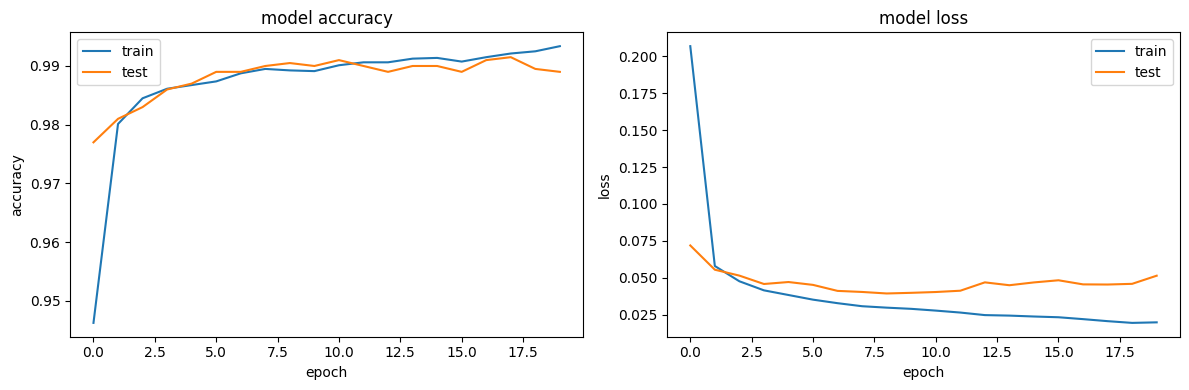

In [17]:
# 학습 정확도 및 손실 시각화
# 학습 과정에서의 성능 변화를 그래프로 확인

plt.figure(figsize=(12,4))  # 전체 그래프 크기 설정

# 정확도 그래프 (왼쪽)
plt.subplot(1, 2, 1)  # 1행 2열 중 첫 번째 그래프
plt.plot(history.history['accuracy'])         # 학습 정확도
plt.plot(history.history['val_accuracy'])     # 검증 정확도
plt.title('model accuracy')
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.legend(['train', 'test'])

# 손실(loss) 그래프 (오른쪽)
plt.subplot(1, 2, 2)  # 1행 2열 중 두 번째 그래프
plt.plot(history.history['loss'])             # 학습 손실
plt.plot(history.history['val_loss'])         # 검증 손실
plt.title('model loss')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['train', 'test'])

plt.tight_layout()
plt.show()